In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib.ticker as ticker

# 1. 파일 불러오기 (인코딩은 상황에 맞게 'euc-kr' 또는 'utf-8' 선택)
# 구글 시트에서 저장한 파일이라면 보통 'utf-8'입니다.
df = pd.read_csv('./data/real_estate_clean_v2.csv', encoding='cp949')
df

C:\Users\gorhk\AppData\Local\Temp\ipykernel_51824\2570270381.py:10: DtypeWarning: Columns (12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/real_estate_clean_v2.csv', encoding='cp949')


,Unnamed: 0.1,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,...,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,QUARTER,QUARTER_INT,CTRT_BLDG_AGE,AMT_PER_AREA,AMT_PER_PYEONG
0,0,14,11530,구로구,10800,오류동,NaN,2018-12-31,73000,197.40,...,NaN,1990,단독다가구,NaN,2018,2018Q4,12,28,369.807497,1222.509625
1,1,16,11215,광진구,10100,중곡동,NaN,2018-12-31,102000,89.09,...,NaN,1973,단독다가구,NaN,2018,2018Q4,12,45,1144.909642,3784.842294
2,2,43,11560,영등포구,10900,영등포동8가,NaN,2018-12-29,88700,36.36,...,NaN,1945,단독다가구,NaN,2018,2018Q4,12,73,2439.493949,8064.479098
3,3,87,11230,동대문구,10900,휘경동,NaN,2018-12-28,95000,140.22,...,NaN,1991,단독다가구,NaN,2018,2018Q4,12,27,677.506775,2239.701897
4,4,92,11620,관악구,10200,신림동,NaN,2018-12-27,56500,179.46,...,NaN,1988,단독다가구,NaN,2018,2018Q4,12,30,314.833389,1040.776218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777302,777302,833566,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,...,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777303,777303,833567,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,...,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777304,777304,833568,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,...,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777305,777305,833569,11650,서초구,10800,서초동,벨라채 오피스텔,2023-12-04,24000,36.64,...,NaN,2003,오피스텔,중개거래,2023,2023Q4,12,20,655.021834,2165.371179


In [3]:
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rc('axes', unicode_minus=False)

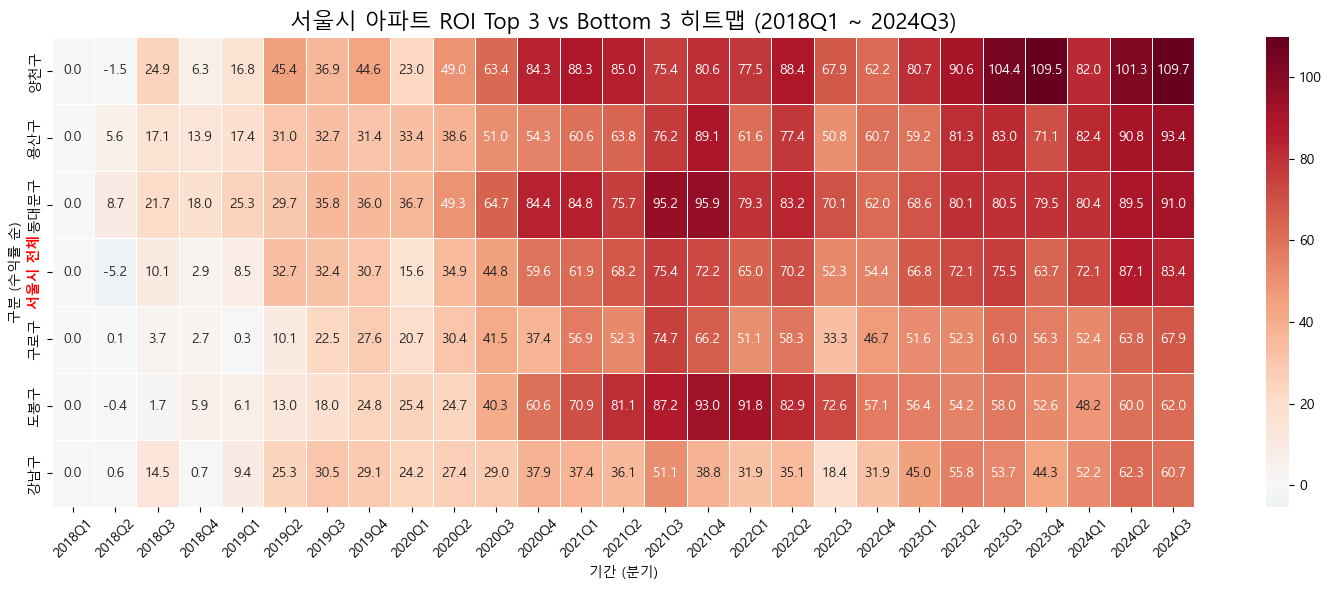

In [4]:
def visualize_roi_top3_bottom3_heatmap(bldg_type, start_year, start_quarter, duration_quarters):
    """
    상위 3개 자치구와 하위 3개 자치구의 기간별 ROI 및 서울시 전체 ROI를 히트맵으로 시각화합니다.
    df 전역 변수의 'QUARTER' 컬럼을 사용합니다.
    """
    # 1. 분석 대상 기간 리스트 생성 (포맷: 2018Q1)
    target_quarters = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        target_quarters.append(f"{current_y}Q{current_q}")
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    # 2. 데이터 필터링
    mask = (
        (df['QUARTER'].isin(target_quarters)) & 
        (df['BLDG_USG'] == bldg_type) &
        (df['CGG_NM'].notnull())
    )
    filtered_df = df.loc[mask].copy()
    
    if filtered_df.empty:
        print("해당 조건의 데이터가 없습니다.")
        return

    # 3. 평단가 집계 & 수익률 계산
    # (1) 개별 자치구
    pivot_price = filtered_df.pivot_table(index='CGG_NM', columns='QUARTER', values='AMT_PER_PYEONG', aggfunc='mean')
    
    # (2) 서울시 전체 Benchmark
    seoul_series = filtered_df.groupby('QUARTER')['AMT_PER_PYEONG'].mean()
    
    # 컬럼 순서 맞추기 (target_quarters 순)
    valid_cols = [q for q in target_quarters if q in pivot_price.columns]
    
    if len(valid_cols) < 2:
        print("시각화할 기간 데이터가 충분하지 않습니다 (최소 2개 분기 필요).")
        return

    pivot_price = pivot_price[valid_cols]
    seoul_series = seoul_series.reindex(valid_cols)
    
    # 자치구 수익률 (기준 시점 대비 누적 수익률)
    base_prices = pivot_price.iloc[:, 0]
    growth_rate_df = pivot_price.div(base_prices, axis=0) # 나눗셈
    growth_rate_df = (growth_rate_df - 1) * 100           # 백분율
    
    # 서울시 수익률
    seoul_ret = (seoul_series / seoul_series.iloc[0] - 1) * 100
    
    # 4. Top 3 / Bottom 3 필터링
    # 최종 수익률 기준 정렬 (마지막 컬럼 값)
    final_returns = growth_rate_df.iloc[:, -1].sort_values(ascending=False)
    
    if len(final_returns) < 6:
        print("자치구 데이터가 부족하여 Top3/Bottom3를 구분할 수 없습니다.")
        # 데이터가 적으면 그냥 전체 출력
        top3 = final_returns.index.tolist()
        bottom3 = []
    else:
        top3 = final_returns.head(3).index.tolist()
        bottom3 = final_returns.tail(3).index.tolist()
    
    # 데이터 추출
    top3_df = growth_rate_df.loc[top3]
    bottom3_df = growth_rate_df.loc[bottom3]
    
    # 서울시 DataFrame 변환
    seoul_df = pd.DataFrame(seoul_ret).T
    seoul_df.index = ['서울시 전체']
    
    # 병합: Top 3 -> 서울시 -> Bottom 3 순서
    final_sorted_df = pd.concat([top3_df, seoul_df, bottom3_df])
    
    # 5. 시각화
    plt.figure(figsize=(15, 6)) # 세로 길이를 줄여서 컴팩트하게
    
    sns.heatmap(final_sorted_df, annot=True, fmt='.1f', cmap='RdBu_r', center=0, linewidths=0.5)
    
    plt.title(f"서울시 {bldg_type} ROI Top 3 vs Bottom 3 히트맵 ({valid_cols[0]} ~ {valid_cols[-1]})", fontsize=16)
    plt.xlabel("기간 (분기)")
    plt.ylabel("구분 (수익률 순)")
    
    # X축 라벨 45도 회전
    plt.xticks(rotation=45)
    
    # '서울시 전체' 강조 (빨간 글씨, 굵게)
    ax = plt.gca()
    for tick in ax.get_yticklabels():
        if tick.get_text() == '서울시 전체':
            tick.set_color('red')
            tick.set_fontweight('bold')
        else:
            tick.set_color('black')
            
    plt.tight_layout()
    plt.show()

# 실행 예시
visualize_roi_top3_bottom3_heatmap("아파트", 2018, 1, 26)

In [7]:
def print_real_estate_backtest_inter_gu(gu1, gu2, bldg_type, start_year, start_quarter, initial_capital, duration_quarters):
    """
    [자치구 vs 자치구] 두 지역의 부동산 투자 성과를 비교하는 표를 출력합니다. (시각화 제외)
    """
    
    # 0. 건물 용도 데이터 존재 여부 검증 (추가된 부분)
    # df는 전역 변수로 가정 (또는 함수 인자로 전달 필요)
    available_types = df['BLDG_USG'].unique()
    if bldg_type not in available_types:
        print(f"⚠️ 오류: 요청하신 건물 용도 '{bldg_type}'는 데이터셋에 존재하지 않습니다.")
        print(f"   (사용 가능한 용도: {list(available_types)})")
        return

    # 1. 분석 대상 기간 리스트 생성
    target_quarters = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        target_quarters.append(f"{current_y}Q{current_q}")
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    # 2. 데이터 필터링
    # (1) 첫 번째 자치구 (gu1)
    mask_1 = (
        (df['QUARTER'].isin(target_quarters)) & 
        (df['BLDG_USG'] == bldg_type) &
        (df['CGG_NM'] == gu1)
    )
    df_1 = df.loc[mask_1].copy()
    
    # (2) 두 번째 자치구 (gu2)
    mask_2 = (
        (df['QUARTER'].isin(target_quarters)) & 
        (df['BLDG_USG'] == bldg_type) &
        (df['CGG_NM'] == gu2)
    )
    df_2 = df.loc[mask_2].copy()
    
    if df_1.empty:
        print(f"[{gu1}] 해당 기간/용도의 데이터가 부족합니다.")
        return
    if df_2.empty:
        print(f"[{gu2}] 해당 기간/용도의 데이터가 부족합니다.")
        return

    # 공통 전처리 함수 (분기별 평단가 Series 생성)
    def get_price_series(temp_df):
        series = temp_df.groupby('QUARTER')['AMT_PER_PYEONG'].mean()
        series = series.reindex(target_quarters).dropna()
        return series

    price_1 = get_price_series(df_1)
    price_2 = get_price_series(df_2)
    
    # 교집합 기간만 비교 (데이터 끊김 방지)
    common_idx = price_1.index.intersection(price_2.index)
    if common_idx.empty:
        print("두 지역 간 겹치는 거래 기간이 없습니다.")
        return
        
    price_1 = price_1.loc[common_idx]
    price_2 = price_2.loc[common_idx]
    
    # 3. 성과 지표 계산 함수
    def calc_metrics(price_series, capital):
        start_p = price_series.iloc[0]
        portfolio = (price_series / start_p) * capital
        
        final_val = portfolio.iloc[-1]
        
        # 수익률
        ret = (final_val / capital - 1) * 100
        
        # CAGR (Quarter 단위이므로 연율화 시 /4)
        years = len(portfolio) / 4
        cagr = ((final_val / capital) ** (1/years) - 1) * 100 if years > 0 else 0
        
        # MDD
        run_max = portfolio.cummax()
        dd = (portfolio / run_max - 1) * 100
        mdd = dd.min()
        
        return final_val, ret, cagr, mdd

    # 계산 수행
    val_1, ret_1, cagr_1, mdd_1 = calc_metrics(price_1, initial_capital)
    val_2, ret_2, cagr_2, mdd_2 = calc_metrics(price_2, initial_capital)
    
    profit_1 = val_1 - initial_capital
    profit_2 = val_2 - initial_capital
    
    # --- [결과 텍스트 출력] (단위: 만원) ---
    print(f"================================================================")
    print(f"      [{gu1} vs {gu2}] {bldg_type} 투자 백테스트 비교")
    print(f"================================================================")
    print(f"1. 투자 기간 : {common_idx[0]} ~ {common_idx[-1]} ({len(common_idx)}분기)")
    print(f"2. 매입 금액 : {initial_capital/10000:,.0f}만 원")
    print(f"----------------------------------------------------------------")
    print(f"   구분        |      {gu1}      |     {gu2}")
    print(f"----------------------------------------------------------------")
    print(f"3. 최종 금액   |  {val_1/10000:,.0f}만 ({profit_1/10000:+,.0f}만) |  {val_2/10000:,.0f}만 ({profit_2/10000:+,.0f}만)")
    print(f"4. 누적 수익률 |     {ret_1:6.2f} %       |     {ret_2:6.2f} %")
    print(f"5. CAGR (연)   |     {cagr_1:6.2f} %       |     {cagr_2:6.2f} %")
    print(f"6. MDD (낙폭)  |     {mdd_1:6.2f} %       |     {mdd_2:6.2f} %")
    print(f"----------------------------------------------------------------")
    
    better_gu = gu1 if ret_1 > ret_2 else gu2
    print(f" * 비교 결과: {better_gu}의 수익률이 더 높습니다.")
    print(f"================================================================")

# 실행 예시 (데이터가 있는 '아파트'로 변경하여 테스트 권장)
print_real_estate_backtest_inter_gu("용산구", "중랑구", "오피스텔", 2018, 1, 300000000, 27)

      [용산구 vs 중랑구] 오피스텔 투자 백테스트 비교
1. 투자 기간 : 2018Q1 ~ 2024Q3 (27분기)
2. 매입 금액 : 30,000만 원
----------------------------------------------------------------
   구분        |      용산구      |     중랑구
----------------------------------------------------------------
3. 최종 금액   |  41,309만 (+11,309만) |  64,768만 (+34,768만)
4. 누적 수익률 |      37.70 %       |     115.89 %
5. CAGR (연)   |       4.85 %       |      12.08 %
6. MDD (낙폭)  |     -28.03 %       |     -44.74 %
----------------------------------------------------------------
 * 비교 결과: 중랑구의 수익률이 더 높습니다.
